    # Clasificación sencilla y vistosa con scikit-learn 🧠✨

¡Bienvenido! En este notebook vamos a construir un modelo de Machine Learning desde cero. Nuestro objetivo es clasificar puntos de datos en dos categorías distintas. 

Aprenderemos a:
1. Generar datos de prueba.
2. Construir un **Pipeline** para evitar "fugas de datos" (data leakage).
3. Encontrar la mejor configuración de nuestro modelo (Hyperparameter tuning).
4. Evaluar los resultados con métricas y gráficas.

In [1]:
# Importación de librerías y configuración visual inicial.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Dict, Any

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay
import joblib

# Configuramos un estilo visual agradable y profesional para todas las gráficas
sns.set_theme(style="whitegrid", palette="muted")
# Fijamos una semilla global sugerida (aunque la pasaremos explícitamente a las funciones)
RANDOM_STATE = 42

## 1. Carga de Datos 📦

Vamos a crear un dataset sintético. Usaremos `make_classification` para generar un problema de 2 características (features). ¿Por qué solo 2? Porque nos permitirá dibujar y visualizar la frontera de decisión en un gráfico 2D fácilmente. 

*Nota: En la vida real podrías usar `load_iris()` o cargar un CSV con `pd.read_csv()`, pero los datos reales suelen tener muchas dimensiones.*

In [2]:
# Función para generar y cargar nuestros datos de prueba.
def load_data(n_samples: int = 300, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    """
    Genera un dataset sintético de clasificación binaria con 2 características informativas.
    
    Args:
        n_samples (int): Número de muestras a generar.
        random_state (int): Semilla para reproducibilidad.
        
    Returns:
        Tuple[np.ndarray, np.ndarray]: X (características) e y (etiquetas).
    """
    # Validamos entradas básicas
    if n_samples < 10:
        raise ValueError("Se necesitan al menos 10 muestras para un dataset válido.")
        
    X, y = make_classification(
        n_samples=n_samples, 
        n_features=2,        # Solo 2 variables para poder graficarlas en X e Y
        n_informative=2,     # Ambas variables aportan información útil
        n_redundant=0,       # Sin variables repetidas
        n_clusters_per_class=1,
        random_state=random_state
    )
    return X, y

# Cargamos los datos
X_full, y_full = load_data(n_samples=300, random_state=RANDOM_STATE)
print(f"Dataset generado: {X_full.shape[0]} filas y {X_full.shape[1]} columnas.")

Dataset generado: 300 filas y 2 columnas.


## 2. Visualización Inicial 🔍

Antes de modelar, ¡siempre hay que mirar los datos! Un diagrama de dispersión (scatter plot) nos ayudará a entender qué tan difícil es separar la Clase 0 de la Clase 1.

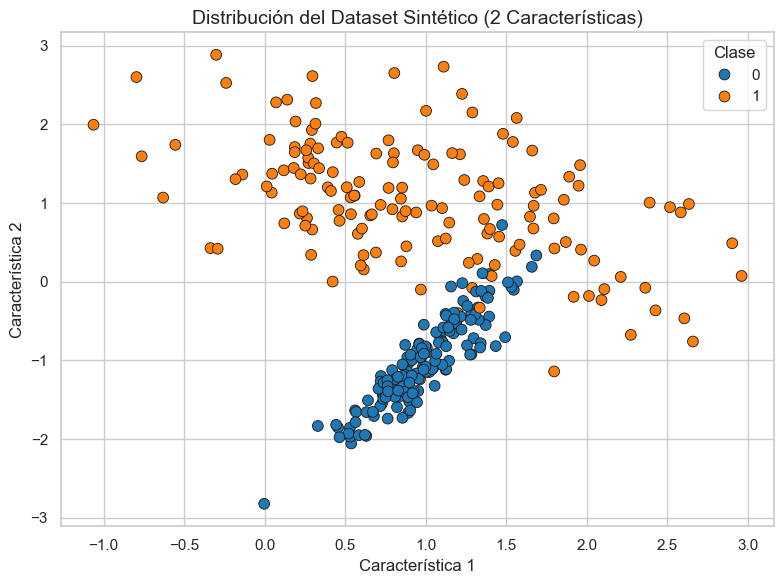

In [3]:
# Graficamos los datos para entender su distribución original.
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_full[:, 0], y=X_full[:, 1], hue=y_full, palette=['#1f77b4', '#ff7f0e'], s=60, edgecolor='k')
plt.title("Distribución del Dataset Sintético (2 Características)", fontsize=14)
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend(title="Clase")
plt.tight_layout()
plt.show()

## 3. Preprocesamiento y Pipelines ⚙️

Los modelos de Machine Learning funcionan mejor si los datos están escalados (por ejemplo, centrados en 0 con varianza 1). 
**¡Regla de oro!** El escalado debe hacerse *solo* con los datos de entrenamiento para evitar "fugas de datos" (que el modelo aprenda cosas del test set antes de tiempo). 

Para garantizar esto, encapsulamos los pasos en un `Pipeline`.

In [ ]:
# Función para construir un Pipeline robusto.
def build_pipeline(model: Any) -> Pipeline:
    """
    Construye un Pipeline que primero escala los datos y luego aplica el modelo.
    
    Args:
        model: Un estimador de scikit-learn (ej. RandomForestClassifier).
        
    Returns:
        Pipeline: Tubería lista para ser entrenada.
    """
    pipeline = Pipeline([
        ('scaler', StandardScaler()), # Paso 1: Normaliza los datos
        ('classifier', model)         # Paso 2: Entrena el modelo
    ])
    return pipeline

## 4. Entrenamiento y Búsqueda de Hiperparámetros 🧠

No existe un modelo perfecto "de fábrica". Usaremos `GridSearchCV` para probar diferentes configuraciones (hiperparámetros) de nuestro `RandomForestClassifier`. `GridSearchCV` usa validación cruzada (`cross_val_score` internamente) para asegurar que el modelo sea robusto y no memorice los datos (overfitting).

In [5]:
# Función para entrenar y buscar los mejores hiperparámetros automáticamente.
def train_and_tune(X_train: np.ndarray, y_train: np.ndarray, pipeline: Pipeline, param_grid: Dict, cv: int = 5):
    """
    Entrena el pipeline probando diferentes hiperparámetros y retorna el mejor modelo.
    """
    print("Iniciando búsqueda de hiperparámetros...")
    # scoring='f1' busca el mejor equilibrio entre precisión y exhaustividad
    grid_search = GridSearchCV(
        estimator=pipeline, 
        param_grid=param_grid, 
        cv=cv, 
        scoring='f1', 
        n_jobs=-1 # Usa todos los núcleos del procesador para ir más rápido
    )
    
    grid_search.fit(X_train, y_train)
    print(f"¡Entrenamiento completado! Mejor score F1 (CV): {grid_search.best_score_:.3f}")
    return grid_search.best_estimator_, grid_search.best_params_

## 5. Evaluación del Modelo 📊

Una vez entrenado, evaluamos el modelo con el conjunto de prueba (`X_test`, `y_test`). Observaremos el reporte clásico de clasificación, una Matriz de Confusión (para ver dónde se equivoca) y la Curva ROC.

In [6]:
# Función para evaluar métricas clave y generar gráficas de rendimiento.
def evaluate(model: Pipeline, X_test: np.ndarray, y_test: np.ndarray):
    """
    Imprime el reporte de clasificación y grafica la matriz de confusión y la curva ROC.
    """
    y_pred = model.predict(X_test)
    
    print("--- Reporte de Clasificación ---")
    print(classification_report(y_test, y_pred))
    
    # Configuramos figura para 2 subgráficos
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Matriz de confusión (Heatmap)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, 
                annot_kws={"size": 14})
    axes[0].set_title('Matriz de Confusión', fontsize=14)
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Valor Real')
    
    # 2. Curva ROC
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1], color='darkorange')
    axes[1].set_title('Curva ROC', fontsize=14)
    axes[1].plot([0, 1], [0, 1], 'k--', label='Azar (AUC = 0.5)')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

## 6. Visualización de la Frontera de Decisión 🎨

Como nuestro dataset tiene solo 2 dimensiones, podemos dibujar exactamente la "línea" (o regiones) que el modelo aprendió para separar las clases.

In [7]:
# Función para visualizar cómo el modelo divide el espacio de características.
def plot_decision_boundary(model: Pipeline, X: np.ndarray, y: np.ndarray):
    """
    Dibuja la región de decisión del modelo sobre un plano 2D.
    """
    # Creamos una malla (grid) que cubra todos nuestros puntos
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    # Predecimos la clase para cada punto de la malla
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 6))
    # Dibujamos las regiones de decisión
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    
    # Dibujamos los puntos reales encima
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=50)
    plt.title("Frontera de Decisión del Modelo", fontsize=14)
    plt.xlabel("Característica 1")
    plt.ylabel("Característica 2")
    plt.legend(*scatter.legend_elements(), title="Clases")
    plt.tight_layout()
    plt.show()

## 7. ¡Todo Junto! 🚀 (Ejecución Principal)

Ahora que tenemos nuestras herramientas listas, vamos a ejecutar todo el flujo: dividir datos, crear el modelo, buscar los mejores parámetros, evaluar, graficar y guardar el modelo en el disco.

Iniciando búsqueda de hiperparámetros...
¡Entrenamiento completado! Mejor score F1 (CV): 0.950
Mejores parámetros encontrados: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.97      0.98        30

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60



C:\Users\PC\Desktop\UNIVERSIDAD\SEXTO SEMESTRE\Probabilidad y estadistica\EjemploExpo\env\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


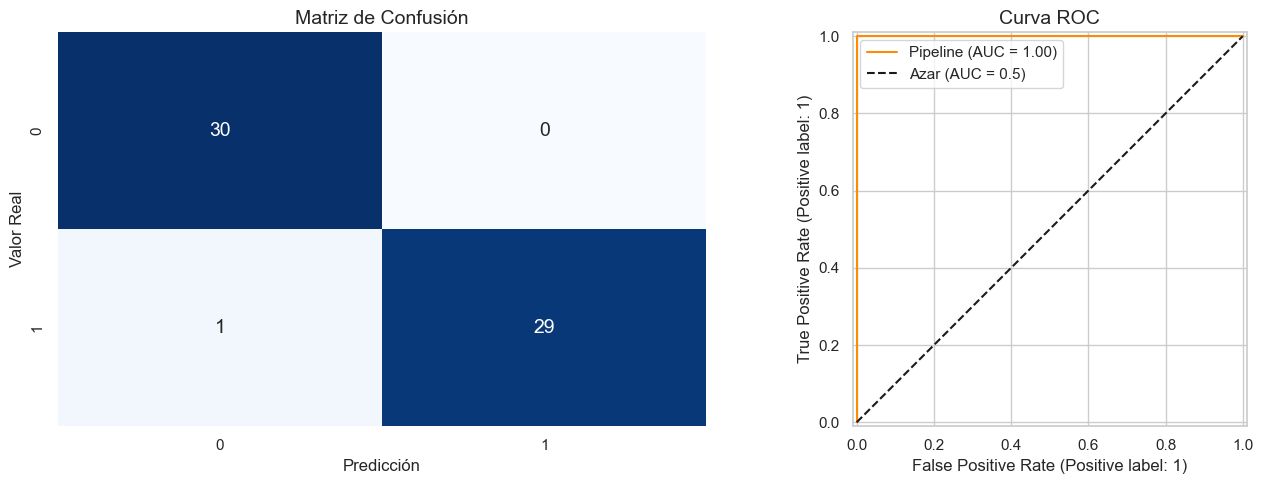

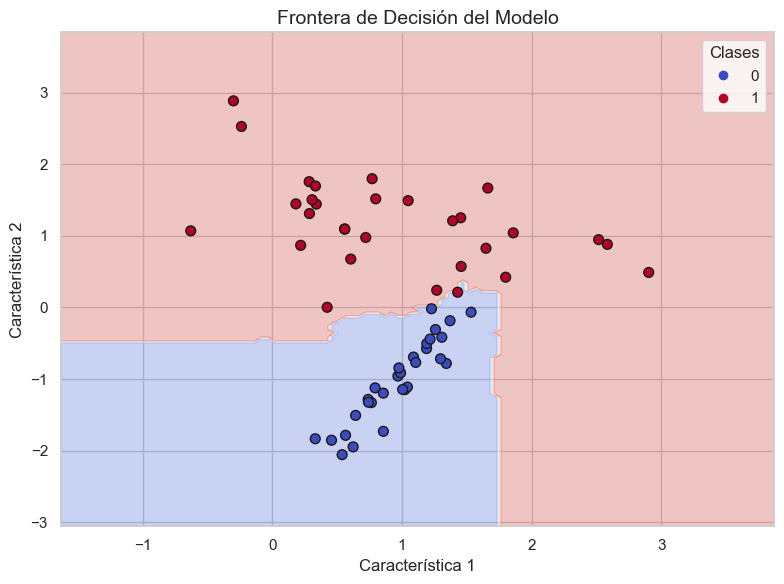

¡Modelo guardado exitosamente como 'mejor_modelo_rf.pkl'!


In [10]:
# Flujo principal: División, Entrenamiento, Evaluación y Guardado.

# 1. División de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)

# 2. Definimos el modelo base y construimos el pipeline
rf_model = RandomForestClassifier(random_state=RANDOM_STATE)
pipeline = build_pipeline(rf_model)

# 3. Definimos la grilla de hiperparámetros a explorar
# Nota: usamos 'classifier__' porque así nombramos al modelo dentro del Pipeline
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5]
}

# 4. Entrenamos y afinamos el modelo
best_model, best_params = train_and_tune(X_train, y_train, pipeline, param_grid)
print(f"Mejores parámetros encontrados: {best_params}")

# 5. Evaluamos en el set de prueba
evaluate(best_model, X_test, y_test)

# 6. Dibujamos la frontera de decisión (usando el test set para ver generalización)
plot_decision_boundary(best_model, X_test, y_test)

# 7. Guardamos el modelo para uso futuro (Persistencia)
filename = 'mejor_modelo_rf.pkl'
joblib.dump(best_model, filename)
print(f"¡Modelo guardado exitosamente como '{filename}'!")

## 8. El Extra: Importancia de las Características 🌟

A veces no basta con saber *qué* predice el modelo, sino *por qué*. Los Random Forest nos permiten ver qué variables fueron más importantes para tomar decisiones.

C:\Users\PC\AppData\Local\Temp\ipykernel_22768\4019603025.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Característica 1', 'Característica 2'], y=importances, palette='viridis')


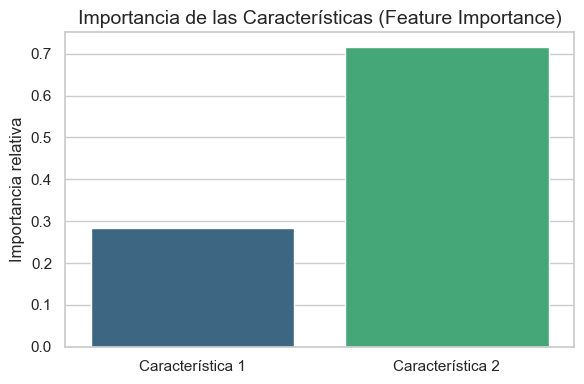

In [11]:
# Extraemos y graficamos la importancia de las variables del RandomForest.
# Accedemos al modelo entrenado extrayéndolo del Pipeline
trained_rf = best_model.named_steps['classifier']
importances = trained_rf.feature_importances_

plt.figure(figsize=(6, 4))
sns.barplot(x=['Característica 1', 'Característica 2'], y=importances, palette='viridis')
plt.title('Importancia de las Características (Feature Importance)', fontsize=14)
plt.ylabel('Importancia relativa')
plt.tight_layout()
plt.show()

## 💡 Resumen de Buenas Prácticas Aplicadas

1. **Evitar Data Leakage**: Usamos `Pipeline` para garantizar que la normalización `StandardScaler` se ajuste (`fit`) únicamente a los datos de entrenamiento.
2. **Validación Cruzada**: Usamos `GridSearchCV`, que particiona el set de entrenamiento internamente, asegurando que los hiperparámetros elegidos sean estables.
3. **Estratificación**: Al usar `train_test_split` aplicamos `stratify=y_full` para mantener la proporción de clases equilibrada entre entrenamiento y prueba.
4. **Reproducibilidad**: Usamos una constante `RANDOM_STATE = 42` a lo largo del código. Esto garantiza que si compartes este notebook, se obtendrán *exactamente* los mismos resultados.
5. **Persistencia**: Usamos `joblib` para exportar el modelo a un archivo `.pkl`, listo para ser consumido por una API o aplicación web.